# Comparing different architecture performance 

## Loading a preparing results

In [1]:
import pandas as pd
from pathlib import Path
import yaml
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt

project_path = Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_DLC\trainingAggression_trainingSessions_topView-MiguelRocha-2026-02-03")
yamlConfig_files = [f for f in project_path.rglob("*.yaml")]

trainConfigs = [f for f in yamlConfig_files if f.name == "pytorch_config.yaml" and f.parent.name == "train"]

In [2]:
trainConfigs

[WindowsPath('C:/Users/stagk/OneDrive/Desktop/trainingAggression_MR/trainingSessions/trainingSessions_topView_DLC/trainingAggression_trainingSessions_topView-MiguelRocha-2026-02-03/dlc-models-pytorch/iteration-0/trainingAggression_trainingSessions_topViewFeb3-trainset95shuffle0/train/pytorch_config.yaml'),
 WindowsPath('C:/Users/stagk/OneDrive/Desktop/trainingAggression_MR/trainingSessions/trainingSessions_topView_DLC/trainingAggression_trainingSessions_topView-MiguelRocha-2026-02-03/dlc-models-pytorch/iteration-0/trainingAggression_trainingSessions_topViewFeb3-trainset95shuffle1/train/pytorch_config.yaml'),
 WindowsPath('C:/Users/stagk/OneDrive/Desktop/trainingAggression_MR/trainingSessions/trainingSessions_topView_DLC/trainingAggression_trainingSessions_topView-MiguelRocha-2026-02-03/dlc-models-pytorch/iteration-0/trainingAggression_trainingSessions_topViewFeb3-trainset95shuffle2/train/pytorch_config.yaml'),
 WindowsPath('C:/Users/stagk/OneDrive/Desktop/trainingAggression_MR/training

In [3]:
models = dict()

for trainConfig in trainConfigs:
    shuffleN = int(re.search(r"shuffle(\d+)", str(trainConfig), re.IGNORECASE).group(1))
    with open(trainConfig, "r") as f:
        model = yaml.safe_load(f)
    
    models[shuffleN] = model["net_type"]
    print(shuffleN)


0
1
2
3
4
5
6
7
8
1
1
2
2
3


In [4]:
combined_results_path = [f for f in project_path.rglob("*CombinedEvaluation-results.csv")]
combined_results_it = len(combined_results_path)

combined_results_iterations = []
for it in range(combined_results_it):
    combined_results_iterations.append(pd.read_csv(combined_results_path[it]))


In [5]:
combined_results = combined_results_iterations[2]

combined_results["model"] = combined_results["Shuffle number"].map(models)
combined_results["delta mAP"] = combined_results["train mAP"] - combined_results["test mAP"]
combined_results["delta mAR"] = combined_results["train mAR"] - combined_results["test mAR"]
combined_results["delta rmse_pcutoff"] = np.abs(combined_results["train rmse_pcutoff"] - combined_results["test rmse_pcutoff"])
combined_results["delta rmse"] = np.abs(combined_results["train rmse"] - combined_results["test rmse"])

pcutoff06 = combined_results[combined_results["pcutoff"] == 0.6].copy()
pcutoff07 = combined_results[combined_results["pcutoff"] == 0.7].copy()
pcutoff08 = combined_results[combined_results["pcutoff"] == 0.8].copy()

In [12]:
combined_results_iterations[3].iloc[:,19:]

,test rmse,test rmse_pcutoff,test mAP,test mAR,test id_head_nose_accuracy,test id_head_rightEar_accuracy,test id_head_leftEar_accuracy,test id_head_neckBase_accuracy,test id_head_betNeckBaseAndMidPoint_accuracy,test id_head_midPoint_accuracy,test id_head_betMidPointAndTailBase_accuracy,test id_head_tailBase_accuracy,test id_head_tailMid_accuracy,test id_head_tailTip_accuracy
0,5.42,4.98,83.8,85.00,1.0,1.00,1.0,1.0,0.92,0.92,1.0,1.0,1.00,0.80
1,5.55,5.01,82.4,86.67,1.0,0.91,1.0,1.0,1.00,1.00,1.0,1.0,0.82,0.82


In [13]:
combined_results_iterations[2].iloc[:,19:]

,test rmse,test rmse_pcutoff,test mAP,test mAR,test id_head_nose_accuracy,test id_head_rightEar_accuracy,test id_head_leftEar_accuracy,test id_head_neckBase_accuracy,test id_head_betNeckBaseAndMidPoint_accuracy,test id_head_midPoint_accuracy,test id_head_betMidPointAndTailBase_accuracy,test id_head_tailBase_accuracy,test id_head_tailMid_accuracy,test id_head_tailTip_accuracy
0,5.58,5.14,81.04,83.20,0.97,0.98,1.0,1.0,1.0,1.0,1.0,1.0,0.98,0.92
1,3.99,3.89,97.60,98.33,1.00,1.00,1.0,1.0,1.0,1.0,1.0,1.0,1.00,0.91


In [6]:
combined_results_iterations[1].iloc[:,19:]

,test rmse,test rmse_pcutoff,test mAP,test mAR,test id_head_nose_accuracy,test id_head_rightEar_accuracy,test id_head_leftEar_accuracy,test id_head_neckBase_accuracy,test id_head_betNeckBaseAndMidPoint_accuracy,test id_head_midPoint_accuracy,test id_head_betMidPointAndTailBase_accuracy,test id_head_tailBase_accuracy,test id_head_tailMid_accuracy,test id_head_tailTip_accuracy
0,5.77,5.24,81.38,84.29,1.0,0.97,0.95,1.0,0.98,0.95,0.89,0.92,0.89,0.92


In [17]:
combined_results_iterations[0].iloc[:,19:]

,test rmse,test rmse_pcutoff,test mAP,test mAR,test id_head_nose_accuracy,test id_head_rightEar_accuracy,test id_head_leftEar_accuracy,test id_head_neckBase_accuracy,test id_head_betNeckBaseAndMidPoint_accuracy,test id_head_midPoint_accuracy,test id_head_betMidPointAndTailBase_accuracy,test id_head_tailBase_accuracy,test id_head_tailMid_accuracy,test id_head_tailTip_accuracy
0,8.13,7.85,78.45,81.39,0.90,0.97,1.00,1.00,0.97,0.97,0.97,1.00,0.94,0.94
1,8.13,7.28,78.45,81.39,0.90,0.97,1.00,1.00,0.97,0.97,0.97,1.00,0.94,0.94
2,6.16,6.10,80.40,83.61,0.95,0.94,0.97,1.00,0.94,0.94,0.94,0.94,0.89,0.85
3,6.16,6.25,80.40,83.61,0.95,0.94,0.97,1.00,0.94,0.94,0.94,0.94,0.89,0.85
4,6.06,4.93,80.37,83.08,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.96,0.88,0.78
5,6.06,4.87,80.37,83.08,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.96,0.88,0.78
6,8.69,8.55,68.35,71.54,0.93,0.96,0.92,0.90,0.92,0.92,0.83,0.83,0.72,0.74
7,8.69,8.62,68.35,71.54,0.93,0.96,0.92,0.90,0.92,0.92,0.83,0.83,0.72,0.74
8,6.66,6.62,76.61,80.38,1.00,0.96,1.00,1.00,1.00,1.00,0.96,0.92,0.88,0.88
9,5.88,6.00,82.70,86.15,0.93,1.00,1.00,1.00,1.00,1.00,1.00,0.96,0.92,0.90


## Train and Test mean Average Precision (mAP), mAR(mean Average Recall), and their difference delta (Generalization metric)

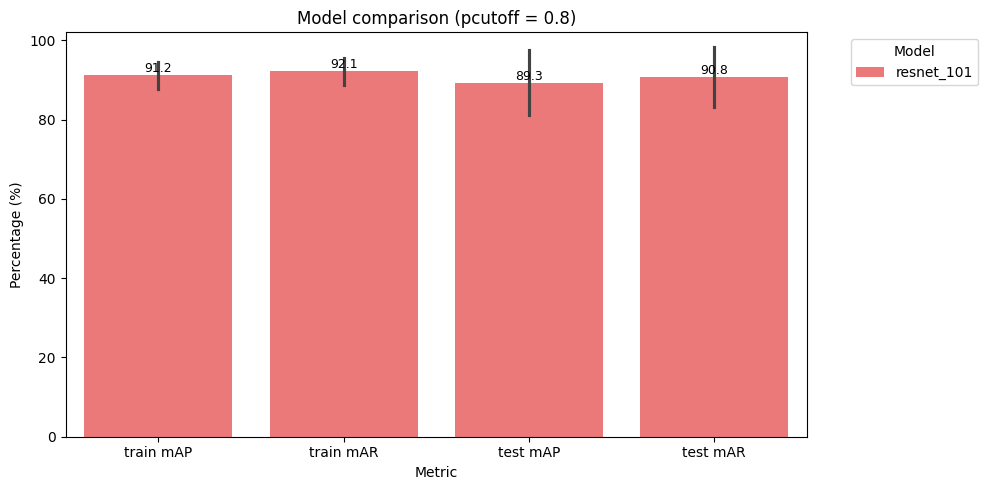

In [15]:
metrics = [
    "train mAP",
    "train mAR",
    "test mAP",
    "test mAR"
]

df_long = pcutoff08.melt(
    id_vars="model",
    value_vars=metrics,
    var_name="metric",
    value_name="value",
)

model_colors = {
    "resnet_50": "#0095ff",         # blue
    "dlcrnet_stride32_ms5": "#ff7700", # orange
    "hrnet_w48": "#00ff00",         # green
    "resnet_101": "#ff0000",        # red
    "dekr_w48": "#cc00ff",
    "cspnext_x": "#0300c2"
}


plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=df_long,
    x="metric",
    y="value",
    hue="model",
    alpha=0.6,
    palette=model_colors
)

# Annotate bars
for p in ax.patches:
    height = p.get_height()
    if np.isnan(height) or height == 0:
        continue
    ax.annotate(
        f"{height:.1f}",                           # format to 1 decimal place
        (p.get_x() + p.get_width() / 2., height),  # center of the bar
        ha='center',                               # horizontal alignment
        va='bottom',                               # vertical alignment
        fontsize=9,
        color='black'
    )

plt.xlabel("Metric")
plt.ylabel("Percentage (%)")
plt.title("Model comparison (pcutoff = 0.8)")

plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.ylim([0,102])
plt.show()

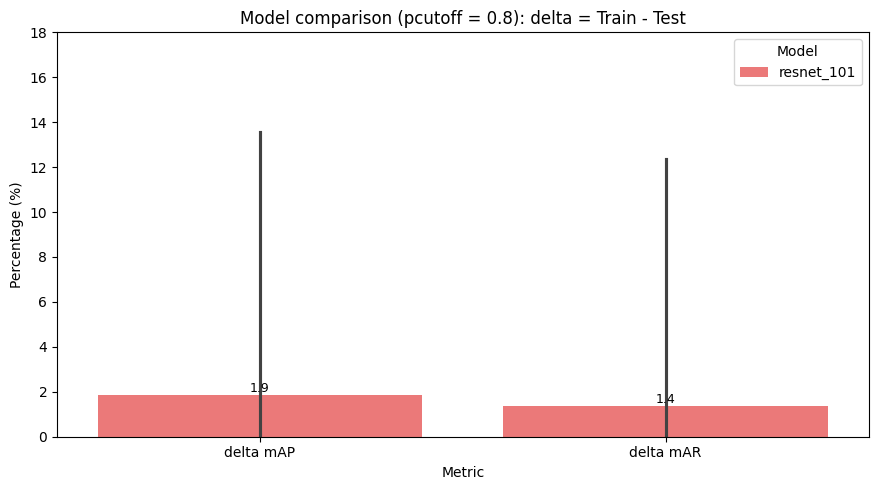

In [16]:
metrics = [
    "delta mAP",
    "delta mAR",
]

df_long = pcutoff08.melt(
    id_vars="model",
    value_vars=metrics,
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=df_long,
    x="metric",
    y="value",
    hue="model",
    alpha=0.6,
    palette=model_colors
)

# Annotate bars
for p in ax.patches:
    height = p.get_height()
    if np.isnan(height) or height == 0:
        continue
    ax.annotate(
        f"{height:.1f}",                            # format to 1 decimal place
        (p.get_x() + p.get_width() / 2., height),   # center of the bar
        ha='center',                                # horizontal alignment
        va='bottom',                                # vertical alignment
        fontsize=9,
        color='black'
    )

plt.xlabel("Metric")
plt.ylabel("Percentage (%)")
plt.title("Model comparison (pcutoff = 0.8): delta = Train - Test")
plt.legend(title="Model")
plt.tight_layout()
plt.ylim([0,18])
plt.show()

## Train and Test root mean square error (rsme), root mean square error with of keypoints filtered with a confidance threshold criterion (rmse pcutoff), and their difference delta (Generalization metric)

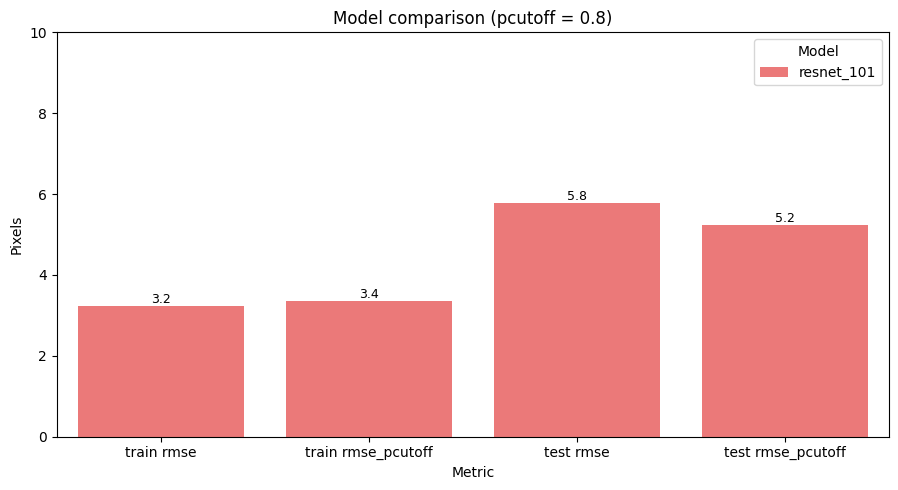

In [171]:
metrics = [
    "train rmse",
    "train rmse_pcutoff",
    "test rmse",
    "test rmse_pcutoff",
]

df_long = pcutoff08.melt(
    id_vars="model",
    value_vars=metrics,
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=df_long,
    x="metric",
    y="value",
    hue="model",
    alpha=0.6,
    palette=model_colors
)

# Annotate bars
for p in ax.patches:
    height = p.get_height()
    if np.isnan(height) or height == 0:
        continue
    
    ax.annotate(
        f"{height:.1f}",                            # format to 1 decimal place
        (p.get_x() + p.get_width() / 2., height),   # center of the bar
        ha='center',                                # horizontal alignment
        va='bottom',                                # vertical alignment
        fontsize=9,
        color='black'
    )

plt.xlabel("Metric")
plt.ylabel("Pixels")
plt.title("Model comparison (pcutoff = 0.8)")
plt.legend(title="Model")
plt.tight_layout()
plt.ylim([0,10])
plt.show()

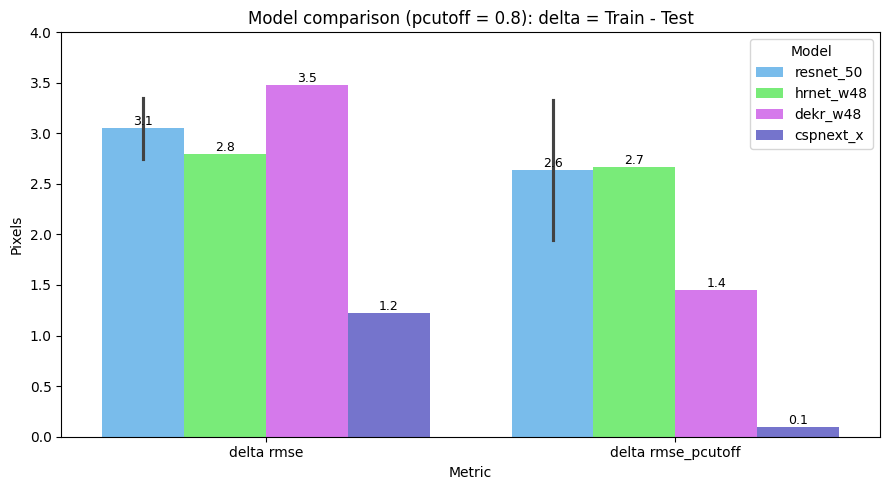

In [122]:
metrics = [
    "delta rmse",
    "delta rmse_pcutoff",
]

df_long = pcutoff08.melt(
    id_vars="model",
    value_vars=metrics,
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=df_long,
    x="metric",
    y="value",
    hue="model",
    alpha=0.6,
    palette=model_colors
)


# Annotate bars
for p in ax.patches:
    height = p.get_height()
    if np.isnan(height) or height == 0:
        continue
    ax.annotate(
        f"{height:.1f}",                            # format to 1 decimal place
        (p.get_x() + p.get_width() / 2., height),   # center of the bar
        ha='center',                                # horizontal alignment
        va='bottom',                                # vertical alignment
        fontsize=9,
        color='black'
    )

plt.xlabel("Metric")
plt.ylabel("Pixels")
plt.title("Model comparison (pcutoff = 0.8): delta = Train - Test")
plt.legend(title="Model")
plt.tight_layout()
plt.ylim([0,4])
plt.show()

## Per keypoint accuracy

In [123]:
id_cols = pcutoff08.columns[pcutoff08.columns.str.contains(r"^(train|test)\s+id_", regex=True)]

long = pcutoff08.melt(
    id_vars=["model"],   
    value_vars=id_cols,
    var_name="col",
    value_name="value"
)

long[["split", "metric"]] = long["col"].str.extract(r"^(train|test)\s+(id_.*)$")

C:\Users\stagk\AppData\Local\Temp\ipykernel_13364\147358702.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  id_cols = pcutoff08.columns[pcutoff08.columns.str.contains(r"^(train|test)\s+id_", regex=True)]


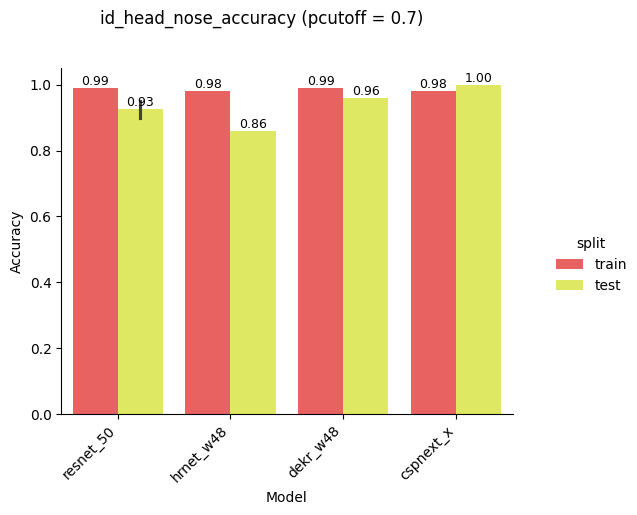

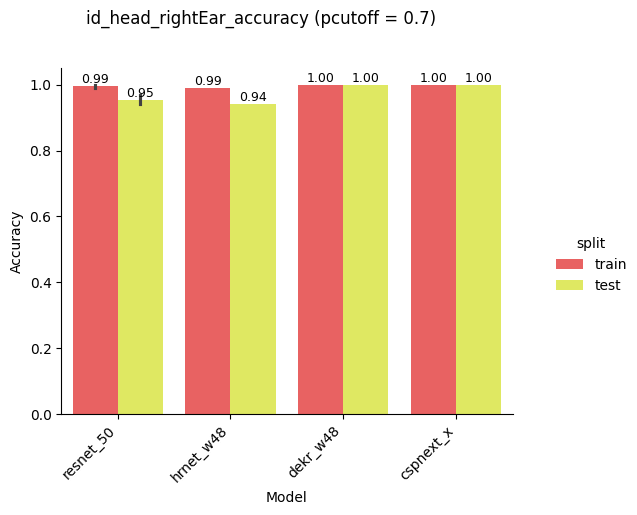

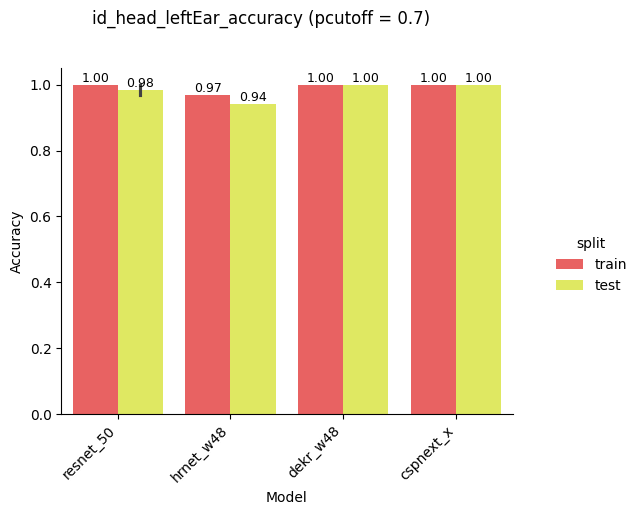

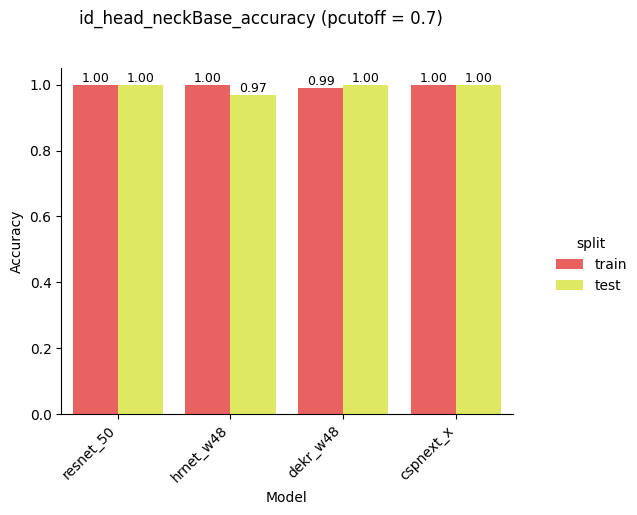

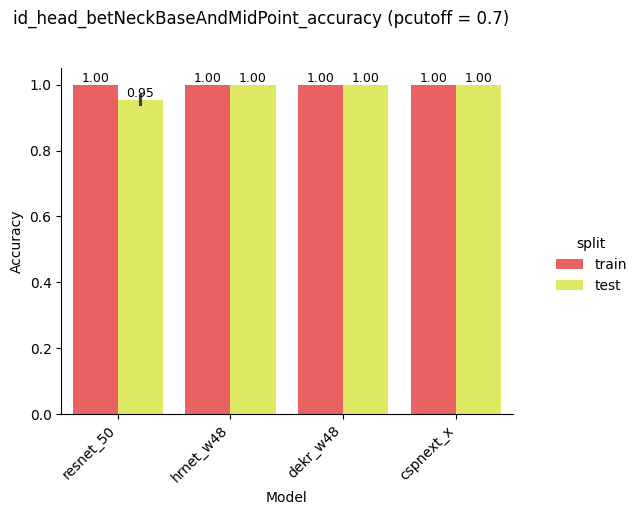

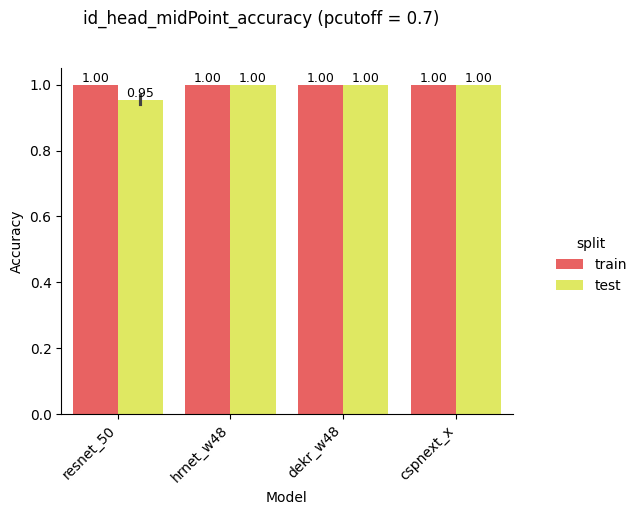

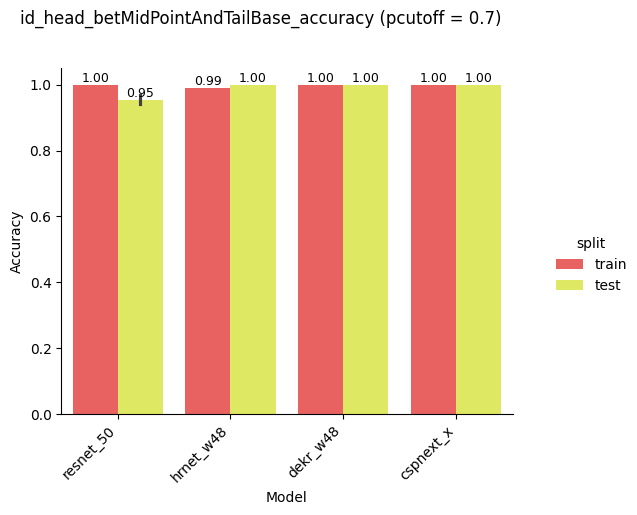

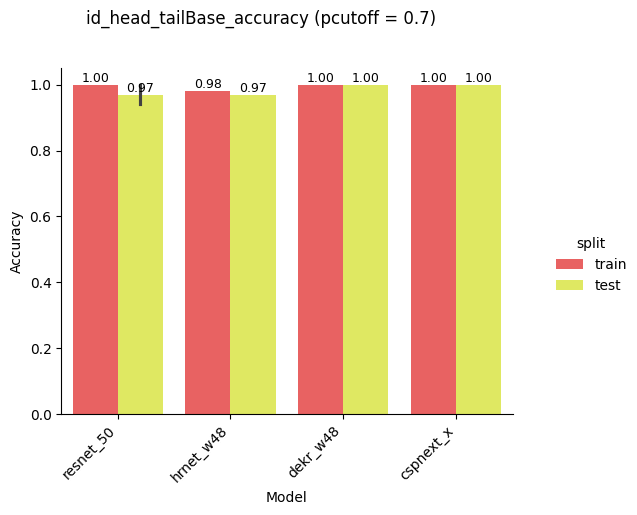

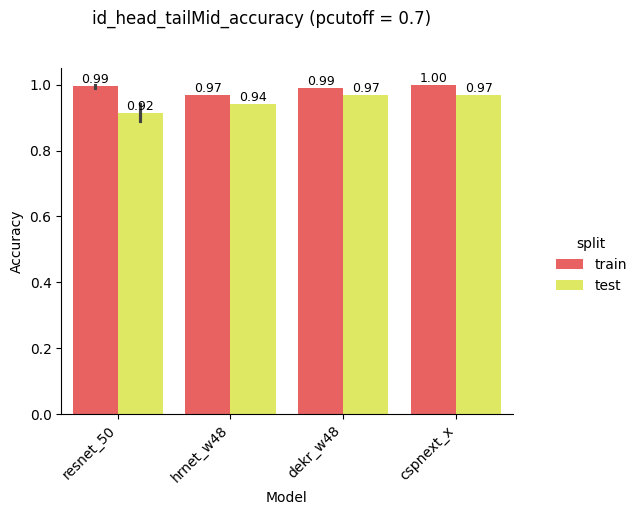

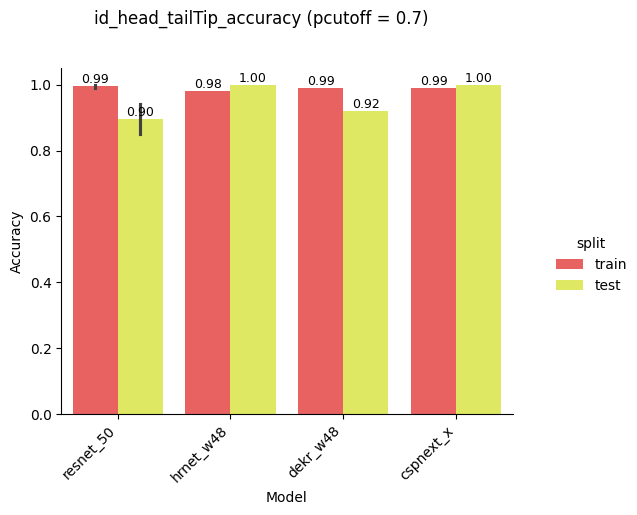

In [124]:
model_colors = {
    "train": "#ff0000",         # blue
    "test": "#eeff00", # orange
}

for metric_name in long["metric"].unique():
    plot_df = long[long["metric"] == metric_name]

    g = sns.catplot(
        data=plot_df,
        x="model", y="value",
        hue="split",
        kind="bar",
        height=5,
        aspect=0.9,
        alpha=0.7,
        palette=model_colors
    )

    ax = g.ax

    # Annotate bars
    for p in ax.patches:
        height = p.get_height()
        if np.isnan(height) or height == 0:
            continue
        ax.annotate(
            f"{height:.2f}", 
            (p.get_x() + p.get_width() / 2., height),
            ha="center",
            va="bottom",
            fontsize=9,
            color="black"
        )

        # Move legend to the right, outside the axes
    if g._legend is not None:
        g._legend.set_title("split")
        g._legend.set_bbox_to_anchor((1.02, 0.5))
        g._legend.set_loc("center left")


    g.set_xticklabels(rotation=45, ha="right")
    g.set_axis_labels("Model", "Accuracy")
    g.fig.suptitle(f"{metric_name} (pcutoff = 0.7)", y=1.02)  # title above plot

    g.fig.tight_layout()
    plt.show()